In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

def process_large_dataset(file_path, output_path):
    # Process the dataset in chunks to handle large files
    chunk_size = 100000  # Adjust chunk size based on memory
    filtered_chunks = []

    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        # Clean 'Installs' column (remove commas and plus signs)
        chunk["Installs"] = chunk["Installs"].astype(str)
        chunk["Installs"] = chunk["Installs"].str.replace(",", "", regex=False)  # Remove commas
        chunk["Installs"] = chunk["Installs"].str.replace("+", "", regex=False)  # Remove plus sign

        # Convert 'Installs' to numeric
        chunk["Installs"] = pd.to_numeric(chunk["Installs"], errors="coerce")

        # Convert 'Last Updated' to datetime
        chunk["Last Updated"] = pd.to_datetime(chunk["Last Updated"], errors="coerce")

        # Filter for relevant conditions
        chunk = chunk[chunk["Installs"] > 10000]  # Installs > 10k
        chunk = chunk[chunk["Content Rating"] == "Teen"]  # Content Rating is 'Teen'
        chunk = chunk[chunk["App"].str.startswith("E")]  # App Name starts with 'E'

        # Append the filtered chunk to the list
        filtered_chunks.append(chunk)

    # Combine all chunks into a single DataFrame
    filtered_data = pd.concat(filtered_chunks, axis=0, ignore_index=True)

    # Save the filtered data to the output file
    filtered_data.to_csv(output_path, index=False)

    return filtered_data

def visualize_data(filtered_data):
    # Ensure data is sorted by 'Last Updated' for time-series visualization
    filtered_data = filtered_data.sort_values(by="Last Updated")

    # Group by 'Last Updated' (by month) and 'Category', sum the installs
    filtered_data['Year-Month'] = filtered_data['Last Updated'].dt.to_period('M')
    installs_by_month_category = filtered_data.groupby(['Year-Month', 'Category'])['Installs'].sum().unstack()

    # Plot the time series
    plt.figure(figsize=(14, 8))
    installs_by_month_category.plot(kind="line", marker='o', figsize=(14, 8))

    # Highlight periods of significant growth (>= 20% month-over-month increase)
    for category in installs_by_month_category.columns:
        category_installs = installs_by_month_category[category]
        growth_rate = category_installs.pct_change(fill_method=None) * 100  # Fix for deprecated warning

        # Highlight periods where growth rate > 20%
        significant_growth = growth_rate[growth_rate > 20]
        for date in significant_growth.index:
            plt.axvspan(date, date, color='yellow', alpha=0.5)

    plt.title("Total Installs Over Time by Category (with Significant Growth Highlighted)")
    plt.xlabel("Date")
    plt.ylabel("Total Installs")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()  # Ensure the plot is displayed

def main():
    # Define the input and output file paths
    input_file = 'google_play_store_dataset.csv'  # Path to your dataset
    output_file = 'filtered_google_play_store_dataset.csv'  # Output path for the filtered data

    # Define the time zone and check the current time
    ist = pytz.timezone("Asia/Kolkata")
    current_time = datetime.now(ist)
    
    # Only proceed if the time is between 6 PM and 9 PM IST
    if 18 <= current_time.hour < 21:  # Time window 6 PM to 9 PM IST
        # Process and filter the dataset
        filtered_data = process_large_dataset(input_file, output_file)

        # Visualize the trend
        if not filtered_data.empty:
            visualize_data(filtered_data)
        else:
            print("No data available for visualization.")
    else:
        print("Current time is not between 6 PM and 9 PM IST.")

if __name__ == "__main__":
    main()


Current time is not between 6 PM and 9 PM IST.


<Figure size 1400x800 with 0 Axes>

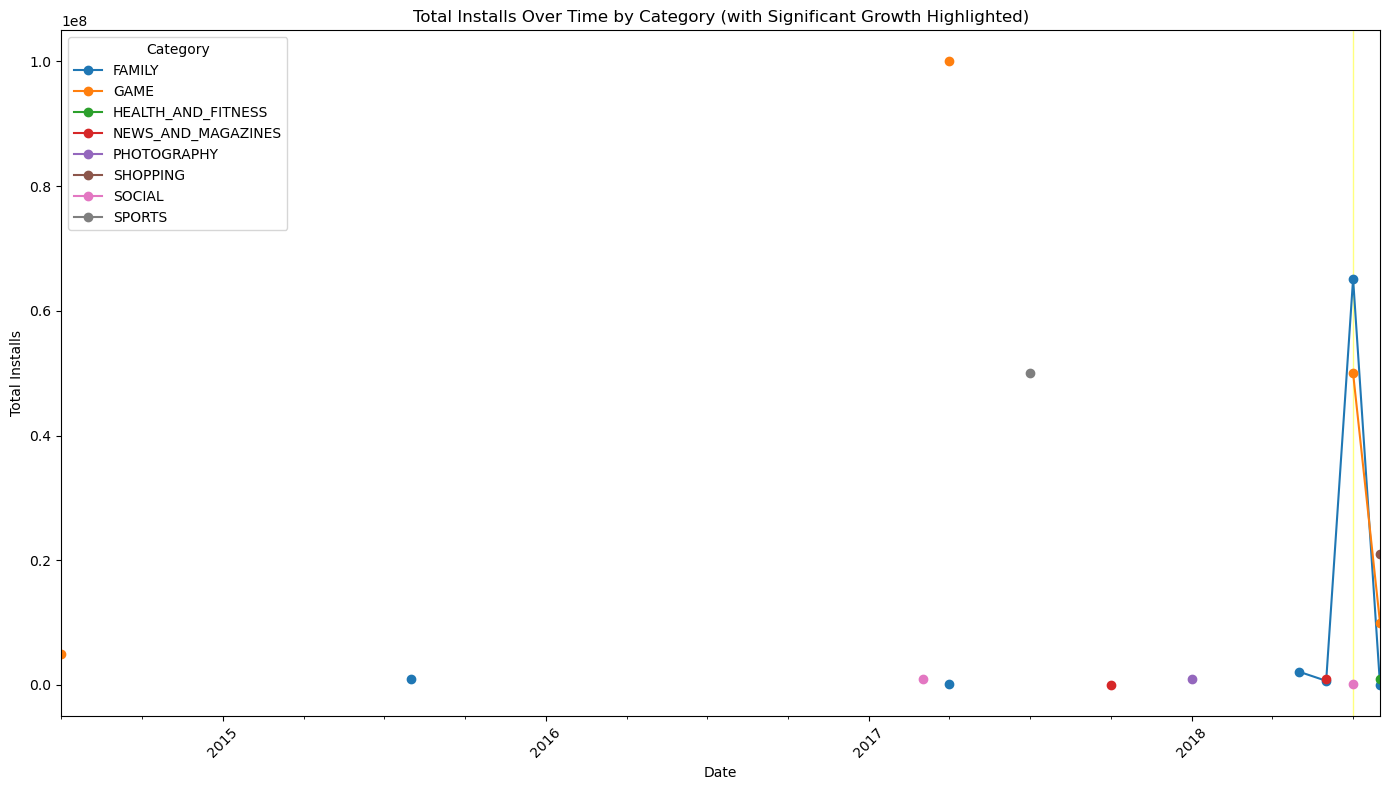

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

def process_large_dataset(file_path, output_path):
    # Process the dataset in chunks to handle large files
    chunk_size = 100000  # Adjust chunk size based on memory
    filtered_chunks = []

    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        # Clean 'Installs' column (remove commas and plus signs)
        chunk["Installs"] = chunk["Installs"].astype(str)
        chunk["Installs"] = chunk["Installs"].str.replace(",", "", regex=False)  # Remove commas
        chunk["Installs"] = chunk["Installs"].str.replace("+", "", regex=False)  # Remove plus sign

        # Convert 'Installs' to numeric
        chunk["Installs"] = pd.to_numeric(chunk["Installs"], errors="coerce")

        # Convert 'Last Updated' to datetime
        chunk["Last Updated"] = pd.to_datetime(chunk["Last Updated"], errors="coerce")

        # Filter for relevant conditions
        chunk = chunk[chunk["Installs"] > 10000]  # Installs > 10k
        chunk = chunk[chunk["Content Rating"] == "Teen"]  # Content Rating is 'Teen'
        chunk = chunk[chunk["App"].str.startswith("E")]  # App Name starts with 'E'

        # Append the filtered chunk to the list
        filtered_chunks.append(chunk)

    # Combine all chunks into a single DataFrame
    filtered_data = pd.concat(filtered_chunks, axis=0, ignore_index=True)

    # Save the filtered data to the output file
    filtered_data.to_csv(output_path, index=False)

    return filtered_data

def visualize_data(filtered_data):
    # Ensure data is sorted by 'Last Updated' for time-series visualization
    filtered_data = filtered_data.sort_values(by="Last Updated")

    # Group by 'Last Updated' (by month) and 'Category', sum the installs
    filtered_data['Year-Month'] = filtered_data['Last Updated'].dt.to_period('M')
    installs_by_month_category = filtered_data.groupby(['Year-Month', 'Category'])['Installs'].sum().unstack()

    # Plot the time series
    plt.figure(figsize=(14, 8))
    installs_by_month_category.plot(kind="line", marker='o', figsize=(14, 8))

    # Highlight periods of significant growth (>= 20% month-over-month increase)
    for category in installs_by_month_category.columns:
        category_installs = installs_by_month_category[category]
        growth_rate = category_installs.pct_change(fill_method=None) * 100  # Fix for deprecated warning

        # Highlight periods where growth rate > 20%
        significant_growth = growth_rate[growth_rate > 20]
        for date in significant_growth.index:
            plt.axvspan(date, date, color='yellow', alpha=0.5)

    plt.title("Total Installs Over Time by Category (with Significant Growth Highlighted)")
    plt.xlabel("Date")
    plt.ylabel("Total Installs")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()  # Ensure the plot is displayed

def main():
    # Define the input and output file paths
    input_file = 'google_play_store_dataset.csv'  # Path to your dataset
    output_file = 'filtered_google_play_store_dataset.csv'  # Output path for the filtered data

    # Define the time zone and check the current time
    ist = pytz.timezone("Asia/Kolkata")
    current_time = datetime.now(ist)
    
    # Only proceed if the time is between 6 PM and 9 PM IST
    if 10 <= current_time.hour < 12:  # Time window 6 PM to 9 PM IST
        # Process and filter the dataset
        filtered_data = process_large_dataset(input_file, output_file)

        # Visualize the trend
        if not filtered_data.empty:
            visualize_data(filtered_data)
        else:
            print("No data available for visualization.")
    else:
        print("Current time is not between 6 PM and 9 PM IST.")

if __name__ == "__main__":
    main()


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

def process_large_dataset(file_path, output_path):
    # Process the dataset in chunks to handle large files
    chunk_size = 100000  # Adjust chunk size based on memory
    filtered_chunks = []

    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        # Clean 'Installs' column (remove commas and plus signs)
        chunk["Installs"] = chunk["Installs"].astype(str)
        chunk["Installs"] = chunk["Installs"].str.replace(",", "", regex=False)  # Remove commas
        chunk["Installs"] = chunk["Installs"].str.replace("+", "", regex=False)  # Remove plus sign

        # Convert 'Installs' to numeric
        chunk["Installs"] = pd.to_numeric(chunk["Installs"], errors="coerce")

        # Convert 'Last Updated' to datetime
        chunk["Last Updated"] = pd.to_datetime(chunk["Last Updated"], errors="coerce")

        # Filter for relevant conditions
        chunk = chunk[chunk["Installs"] > 10000]  # Installs > 10k
        chunk = chunk[chunk["Content Rating"] == "Teen"]  # Content Rating is 'Teen'
        chunk = chunk[chunk["App"].str.startswith("E")]  # App Name starts with 'E'

        # Append the filtered chunk to the list
        filtered_chunks.append(chunk)

    # Combine all chunks into a single DataFrame
    filtered_data = pd.concat(filtered_chunks, axis=0, ignore_index=True)

    # Save the filtered data to the output file
    filtered_data.to_csv(output_path, index=False)

    return filtered_data

def visualize_data(filtered_data):
    # Ensure data is sorted by 'Last Updated' for time-series visualization
    filtered_data = filtered_data.sort_values(by="Last Updated")

    # Group by 'Last Updated' (by month) and 'Category', sum the installs
    filtered_data['Year-Month'] = filtered_data['Last Updated'].dt.to_period('M')
    installs_by_month_category = filtered_data.groupby(['Year-Month', 'Category'])['Installs'].sum().unstack()

    # Plot the time series
    plt.figure(figsize=(14, 8))
    installs_by_month_category.plot(kind="line", marker='o', figsize=(14, 8))

    # Highlight periods of significant growth (>= 20% month-over-month increase)
    for category in installs_by_month_category.columns:
        category_installs = installs_by_month_category[category]
        growth_rate = category_installs.pct_change(fill_method=None) * 100  # Fix for deprecated warning

        # Find the start and end points where growth > 20%
        significant_growth = growth_rate[growth_rate > 20]
        for i in range(1, len(significant_growth)):
            start_date = significant_growth.index[i - 1]
            end_date = significant_growth.index[i]
            plt.axvspan(start_date, end_date, color='yellow', alpha=0.5)

    plt.title("Total Installs Over Time by Category (with Significant Growth Highlighted)")
    plt.xlabel("Date")
    plt.ylabel("Total Installs")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()  # Ensure the plot is displayed

def main():
    # Define the input and output file paths
    input_file = 'google_play_store_dataset.csv'  # Path to your dataset
    output_file = 'filtered_google_play_store_dataset.csv'  # Output path for the filtered data

    # Define the time zone and check the current time
    ist = pytz.timezone("Asia/Kolkata")
    current_time = datetime.now(ist)
    
    # Only proceed if the time is between 6 PM and 9 PM IST
    if 18 <= current_time.hour < 21:  # Time window 6 PM to 9 PM IST
        # Process and filter the dataset
        filtered_data = process_large_dataset(input_file, output_file)

        # Visualize the trend
        if not filtered_data.empty:
            visualize_data(filtered_data)
        else:
            print("No data available for visualization.")
    else:
        print("Current time is not between 6 PM and 9 PM IST.")

if __name__ == "__main__":
    main()


Current time is not between 6 PM and 9 PM IST.


<Figure size 1400x800 with 0 Axes>

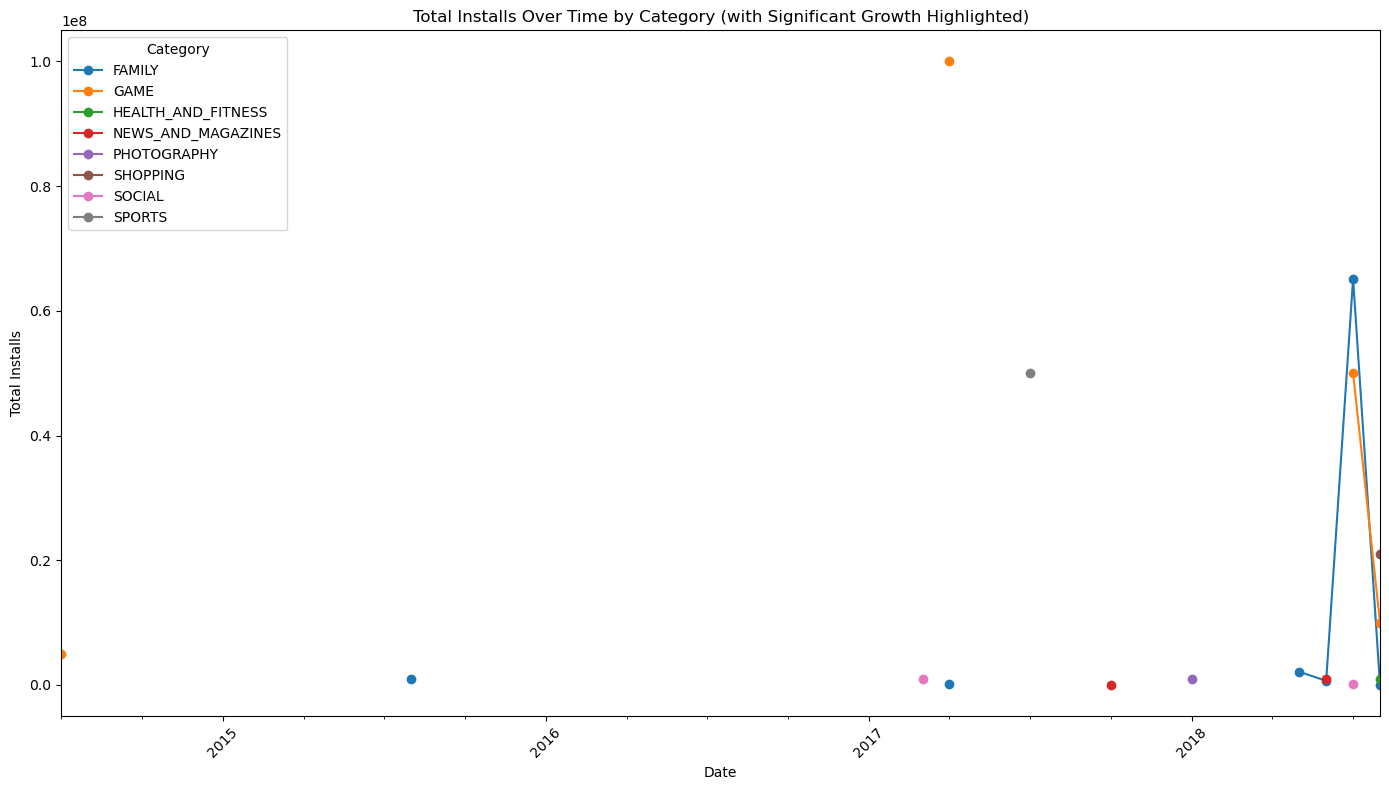

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import pytz

def process_large_dataset(file_path, output_path):
    # Process the dataset in chunks to handle large files
    chunk_size = 100000  # Adjust chunk size based on memory
    filtered_chunks = []

    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        # Clean 'Installs' column (remove commas and plus signs)
        chunk["Installs"] = chunk["Installs"].astype(str)
        chunk["Installs"] = chunk["Installs"].str.replace(",", "", regex=False)  # Remove commas
        chunk["Installs"] = chunk["Installs"].str.replace("+", "", regex=False)  # Remove plus sign

        # Convert 'Installs' to numeric
        chunk["Installs"] = pd.to_numeric(chunk["Installs"], errors="coerce")

        # Convert 'Last Updated' to datetime
        chunk["Last Updated"] = pd.to_datetime(chunk["Last Updated"], errors="coerce")

        # Filter for relevant conditions
        chunk = chunk[chunk["Installs"] > 10000]  # Installs > 10k
        chunk = chunk[chunk["Content Rating"] == "Teen"]  # Content Rating is 'Teen'
        chunk = chunk[chunk["App"].str.startswith("E")]  # App Name starts with 'E'

        # Append the filtered chunk to the list
        filtered_chunks.append(chunk)

    # Combine all chunks into a single DataFrame
    filtered_data = pd.concat(filtered_chunks, axis=0, ignore_index=True)

    # Save the filtered data to the output file
    filtered_data.to_csv(output_path, index=False)

    return filtered_data

def visualize_data(filtered_data):
    # Ensure data is sorted by 'Last Updated' for time-series visualization
    filtered_data = filtered_data.sort_values(by="Last Updated")

    # Group by 'Last Updated' (by month) and 'Category', sum the installs
    filtered_data['Year-Month'] = filtered_data['Last Updated'].dt.to_period('M')
    installs_by_month_category = filtered_data.groupby(['Year-Month', 'Category'])['Installs'].sum().unstack()

    # Plot the time series
    plt.figure(figsize=(14, 8))
    installs_by_month_category.plot(kind="line", marker='o', figsize=(14, 8))

    # Highlight periods of significant growth (>= 20% month-over-month increase)
    for category in installs_by_month_category.columns:
        category_installs = installs_by_month_category[category]
        growth_rate = category_installs.pct_change(fill_method=None) * 100  # Fix for deprecated warning

        # Find the start and end points where growth > 20%
        significant_growth = growth_rate[growth_rate > 20]
        for i in range(1, len(significant_growth)):
            start_date = significant_growth.index[i - 1]
            end_date = significant_growth.index[i]
            plt.axvspan(start_date, end_date, color='yellow', alpha=0.5)

    plt.title("Total Installs Over Time by Category (with Significant Growth Highlighted)")
    plt.xlabel("Date")
    plt.ylabel("Total Installs")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()  # Ensure the plot is displayed

def main():
    # Define the input and output file paths
    input_file = 'google_play_store_dataset.csv'  # Path to your dataset
    output_file = 'filtered_google_play_store_dataset.csv'  # Output path for the filtered data

    # Define the time zone and check the current time
    ist = pytz.timezone("Asia/Kolkata")
    current_time = datetime.now(ist)
    
    # Only proceed if the time is between 6 PM and 9 PM IST
    if 10 <= current_time.hour < 12:  # Time window 6 PM to 9 PM IST
        # Process and filter the dataset
        filtered_data = process_large_dataset(input_file, output_file)

        # Visualize the trend
        if not filtered_data.empty:
            visualize_data(filtered_data)
        else:
            print("No data available for visualization.")
    else:
        print("Current time is not between 6 PM and 9 PM IST.")

if __name__ == "__main__":
    main()
